<a href="https://colab.research.google.com/github/AkshayMendiratta2006/IncodeVision-ML-Internship/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IncodeVision ML Internship - Task 02
**Project:** Linear Regression Model

**Desciption:**
This notebook builds a Linear Regression model using Python and scikit-learn to predict house prices based on various features (area, bedrooms, location, etc.). The dataset is preprocessed using pandas to handle categorical variables. The model is evaluated using Mean Squared Error (MSE) and R-squared ($R^2$) metrices, and the actual vs. predicted values are visualized using Seaborn and Matplotlib.

**Dataset:**
The Dataset used for this project is the **Housing Prices Dataset**.
* You can download the dataset from Kaggle here: [Housing Prices Dataset on Kaggle](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

In [12]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# Uploading Dataset
df = pd.read_csv('Housing.csv')
display(df.head())
print('\n--- Dataset Info ---\n')
df.info()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



--- Dataset Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [14]:
# Data Preprocessing
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[binary_columns] = df[binary_columns].replace({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)
print('\n--- Preprocessing Dataset Info ---\n')
df.info()
display(df.head())


--- Preprocessing Dataset Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingsta

/tmp/ipykernel_420/570330647.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_columns] = df[binary_columns].replace({'yes': 1, 'no': 0})


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [15]:
# Train - Test Spilt
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training data shape: {X_train.shape}')
print(f'Testing data shape: {X_test.shape}')

Training data shape: (436, 13)
Testing data shape: (109, 13)


In [16]:
# Training the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
# Predicting on Test Set
y_pred = model.predict(X_test)

In [18]:
# Evaluating the predictions based on MSE and R-squared evaluation metrices
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('\n--- Model Evaluation ---\n')
print(f'Mean Squared Error (MSE): {mse:,.2f}')
print(f'R-squared (R2): {r2:.4f}')


--- Model Evaluation ---

Mean Squared Error (MSE): 1,754,318,687,330.66
R-squared (R2): 0.6529


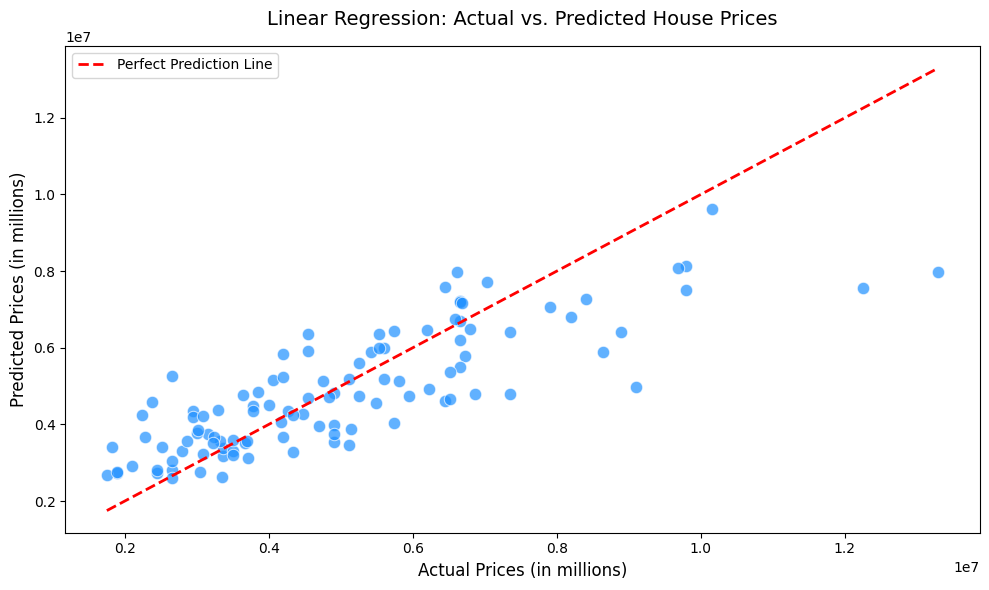

In [19]:
# Visualize Actual vs Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='dodgerblue', edgecolor='w', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label = 'Perfect Prediction Line')
plt.title('Linear Regression: Actual vs. Predicted House Prices', fontsize=14, pad=15)
plt.xlabel('Actual Prices (in millions)', fontsize=12)
plt.ylabel('Predicted Prices (in millions)', fontsize=12)
plt.legend()
plt.tight_layout()

plt.show()